In [4]:
pip install pymongo pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.5 MB/s eta 0:00:00


In [5]:
pip install pymongo certifi

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf # Data from Yahoo Finance
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from pymongo import MongoClient, UpdateOne
import certifi

# ETL

In [7]:
def ETL():

    # --- DOWNLOAD ---
    tickers = {
        "SP500": "^GSPC",
        "VIX": "^VIX",
        "MOVE": "^MOVE",
        "VIX3M": "^VIX3M",
        "DXY": "DX-Y.NYB",
        "GOLD": "GC=F",
        "OIL": "CL=F",
        "HYG": "HYG",
        "LQD": "LQD"
    }

    data = {}
    for name, ticker in tickers.items():
        df = yf.Ticker(ticker).history(period="20y")

        # Drop
        df = df.drop(columns=["Dividends", "Stock Splits"], errors="ignore")

        if name != "SP500":
            df = df.drop(columns=["Volume"], errors="ignore")

        df = df.rename(columns={
            "Open": f"Open_{name}",
            "High": f"High_{name}",
            "Low": f"Low_{name}",
            "Close": f"Close_{name}",
            "Volume": f"Volume_{name}"
        })

        df.index = df.index.tz_localize(None)

        data[name] = df

    # --- MERGE + ALIGNMENT ---
    dataset = pd.concat(data.values(), axis=1).sort_index()

    dataset = dataset.asfreq("B")
    dataset = dataset.ffill()

    # --- RETURNS ---
    dataset["Return_SPX"]  = dataset["Close_SP500"].pct_change()
    dataset["Return_VIX"]  = dataset["Close_VIX"].pct_change()
    dataset["Return_MOVE"] = dataset["Close_MOVE"].pct_change()
    dataset["Return_VIX3M"]= dataset["Close_VIX3M"].pct_change()

    # --- VOL ---
    dataset["RV_5d"]  = dataset["Return_SPX"].rolling(5).std() * np.sqrt(252)
    dataset["RV_10d"] = dataset["Return_SPX"].rolling(10).std() * np.sqrt(252)
    dataset["RV_21d"] = dataset["Return_SPX"].rolling(21).std() * np.sqrt(252)

    dataset["VIX_Vol_5d"]  = dataset["Return_VIX"].rolling(5).std()
    dataset["VIX_Vol_10d"] = dataset["Return_VIX"].rolling(10).std()
    dataset["VIX_Vol_21d"] = dataset["Return_VIX"].rolling(21).std()

    # --- LAGS / MAs ---
    dataset["VIX_Lag1"] = dataset["Close_VIX"].shift(1)
    dataset["VIX_Lag2"] = dataset["Close_VIX"].shift(2)
    dataset["VIX_Lag5"] = dataset["Close_VIX"].shift(5)

    dataset["VIX_MA_5"]  = dataset["Close_VIX"].rolling(5).mean()
    dataset["VIX_MA_10"] = dataset["Close_VIX"].rolling(10).mean()
    dataset["VIX_MA_20"] = dataset["Close_VIX"].rolling(20).mean()

    dataset["VIX_STD_5"]  = dataset["Close_VIX"].rolling(5).std()
    dataset["VIX_STD_10"] = dataset["Close_VIX"].rolling(10).std()
    dataset["VIX_STD_20"] = dataset["Close_VIX"].rolling(20).std()

    # --- NO DATA LEAKAGE ---
    dataset["VIX_Percentile"] = dataset["Close_VIX"].rolling(252).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1]
    )

    # --- VOLUME ---
    dataset["SPX_Volume_Norm"] = dataset["Volume_SP500"] / (
        dataset["Volume_SP500"].rolling(252).mean() + 1e-8
    )

    # --- STRUCTURE ---
    dataset["VIX3M_Spread"] = dataset["Close_VIX"] - dataset["Close_VIX3M"]
    dataset["VIX_Contango"] = dataset["Close_VIX3M"] / (dataset["Close_VIX"] + 1e-8) - 1

    # --- GAPS ---
    dataset["SPX_Gap"] = (
        dataset["Open_SP500"] - dataset["Close_SP500"].shift(1)
    ) / dataset["Close_SP500"].shift(1)

    dataset["VIX_Gap"] = (
        dataset["Open_VIX"] - dataset["Close_VIX"].shift(1)
    ) / dataset["Close_VIX"].shift(1)

    # --- TREND / MOMENTUM ---
    dataset["Drawdown"] = dataset["Close_SP500"] / dataset["Close_SP500"].cummax() - 1

    dataset["Momentum_1M"] = dataset["Close_SP500"] / dataset["Close_SP500"].shift(21) - 1
    dataset["Momentum_3M"] = dataset["Close_SP500"] / dataset["Close_SP500"].shift(63) - 1
    dataset["Momentum_6M"] = dataset["Close_SP500"] / dataset["Close_SP500"].shift(126) - 1

    # --- ZSCORE FIXED ---
    dataset["VIX_Zscore"] = (
        dataset["Close_VIX"] - dataset["VIX_MA_20"]
    ) / (dataset["VIX_STD_20"] + 1e-8)

    dataset["VIX_MeanRev"] = dataset["Close_VIX"] - dataset["VIX_MA_10"]

    # --- RATIOS SAFE ---
    dataset["IV_RV_Ratio"] = dataset["Close_VIX"] / (dataset["RV_21d"] + 1e-8)
    dataset["VIX_RV_Spread"] = dataset["Close_VIX"] - dataset["RV_21d"]

    dataset["VIX_Trend"] = (
        dataset["Close_VIX"].ewm(span=21, adjust=False).mean()
        - dataset["Close_VIX"].ewm(span=63, adjust=False).mean()
    )

    dataset["VIX_MOVE_Ratio"] = dataset["Close_VIX"] / (dataset["Close_MOVE"] + 1e-8)

    dataset["SPX_VIX_Corr_21d"] = dataset["Return_SPX"].rolling(21).corr(dataset["Return_VIX"])

    dataset["RV_21d_Sq"] = dataset["RV_21d"] ** 2
    dataset["VIX_Zscore_Sq"] = dataset["VIX_Zscore"] ** 2

    # --- TARGET SIN LEAKAGE ---
    dataset["Intraday_VIX_Return"] = (
        dataset["Close_VIX"] - dataset["Open_VIX"]
    ) / dataset["Open_VIX"]

    # rolling quantiles (NO leakage)
    dataset["q_up"] = dataset["Intraday_VIX_Return"].rolling(252).quantile(0.66)
    dataset["q_down"] = dataset["Intraday_VIX_Return"].rolling(252).quantile(0.33)

    dataset["Intraday_VIX_Move"] = np.where(
        dataset["Intraday_VIX_Return"] >= dataset["q_up"], 1,
        np.where(dataset["Intraday_VIX_Return"] <= dataset["q_down"], -1, 0)
    )

    # --- FEATURES ---
    feature_cols = [
        "Open_SP500","Open_VIX","Open_MOVE",
        "Drawdown",
        "Momentum_1M","Momentum_3M","Momentum_6M",
        "RV_5d","RV_10d","RV_21d",
        "VIX_Vol_5d","VIX_Vol_10d","VIX_Vol_21d",
        "VIX_Lag1","VIX_Lag2","VIX_Lag5",
        "VIX_MA_5","VIX_MA_10","VIX_MA_20",
        "VIX_STD_5","VIX_STD_10","VIX_Percentile",
        "SPX_Volume_Norm",
        "VIX3M_Spread","VIX_Contango",
        "SPX_Gap","VIX_Gap",
        "VIX_Zscore","VIX_Zscore_Sq","VIX_MeanRev",
        "IV_RV_Ratio","VIX_RV_Spread","VIX_Trend",
        "VIX_MOVE_Ratio","SPX_VIX_Corr_21d","RV_21d_Sq",
        "Close_DXY","Close_GOLD","Close_OIL",
        "Close_HYG","Close_LQD"
    ]

    dataset_final = dataset[feature_cols + ["Intraday_VIX_Move"]].dropna()

    return dataset_final, dataset

In [9]:
data, dataset =ETL()
data.tail()

,Open_SP500,Open_VIX,Open_MOVE,Drawdown,Momentum_1M,Momentum_3M,Momentum_6M,RV_5d,RV_10d,RV_21d,...,VIX_Trend,VIX_MOVE_Ratio,SPX_VIX_Corr_21d,RV_21d_Sq,Close_DXY,Close_GOLD,Close_OIL,Close_HYG,Close_LQD,Intraday_VIX_Move
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-16,6674.370117,25.879999,91.169998,-0.040011,-0.020010,-0.003281,0.005255,0.145615,0.143269,0.120540,...,3.003997,0.275777,-0.900256,0.014530,99.709999,4994.000000,93.500000,79.449997,108.690002,-1
2026-03-17,6722.350098,24.559999,85.250000,-0.037616,-0.017565,-0.008660,0.003337,0.150621,0.139897,0.121092,...,2.878428,0.282343,-0.900972,0.014663,99.580002,5001.000000,96.209999,79.809998,109.300003,-1
2026-03-18,6697.160156,21.510000,79.230003,-0.050712,-0.031932,-0.030697,-0.004840,0.170869,0.141630,0.128660,...,2.921937,0.308800,-0.904354,0.016554,100.089996,4889.899902,96.320000,79.400002,108.709999,1
2026-03-19,6583.120117,25.600000,81.250000,-0.053322,-0.039937,-0.039544,-0.004742,0.141791,0.141196,0.126095,...,2.890505,0.283459,-0.895426,0.015900,99.230003,4600.700195,96.139999,79.660004,109.190002,-1
2026-03-20,6594.660156,24.459999,84.875298,-0.067653,-0.051795,-0.058368,-0.014874,0.170148,0.145134,0.134177,...,3.016884,0.246039,-0.894705,0.018004,99.502998,4574.899902,98.230003,78.919998,107.849998,1


In [10]:
dataset["Intraday_VIX_Move"]. value_counts()

,count
Intraday_VIX_Move,
0,1889
1,1706
-1,1625


In [12]:
uri = BLURED
client = MongoClient(uri, tls=True, tlsCAFile=certifi.where())

db = client["DB_VIX"]
collection = db["vix_data"]

data_mongo = data.copy()
data_mongo["_id"] = data_mongo.index.astype(str)  # use datetime as _id

records = data_mongo.to_dict("records")

operations = [
    UpdateOne(
        {"_id": r["_id"]},
        {"$set": r},  # will insert new fields if they exist
        upsert=True
    )
    for r in records
]

if operations:
    result = collection.bulk_write(operations)
    print(f"Inserted or updated records: {result.upserted_count + result.modified_count}")
else:
    print("No new data to insert/update")

Inserted or updated records: 4943


# Model

### Walk-forward expanding window

Split 1
Initial training only
--------------------------------------------------
Split 2
Train size: 100 / Test size: 1
Train From: 2023-11-29 to 2024-04-23
Test Date: 2024-04-24
--------------------------------------------------
Split 3
Train size: 100 / Test size: 1
Train From: 2023-11-30 to 2024-04-24
Test Date: 2024-04-25
--------------------------------------------------
Split 4
Train size: 100 / Test size: 1
Train From: 2023-12-01 to 2024-04-25
Test Date: 2024-04-26
--------------------------------------------------
Split 5
Train size: 100 / Test size: 1
Train From: 2023-12-04 to 2024-04-26
Test Date: 2024-04-29
--------------------------------------------------


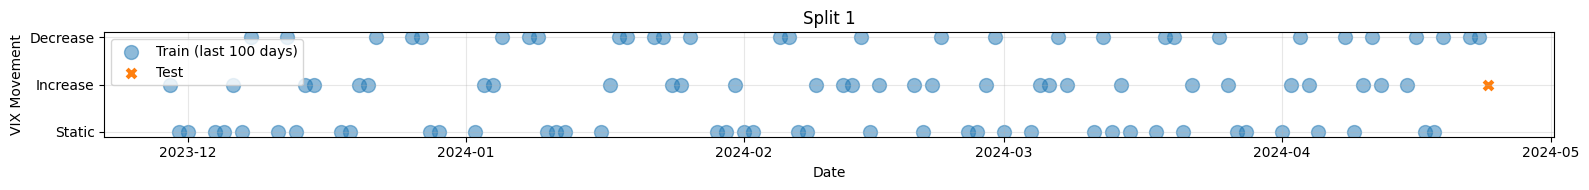

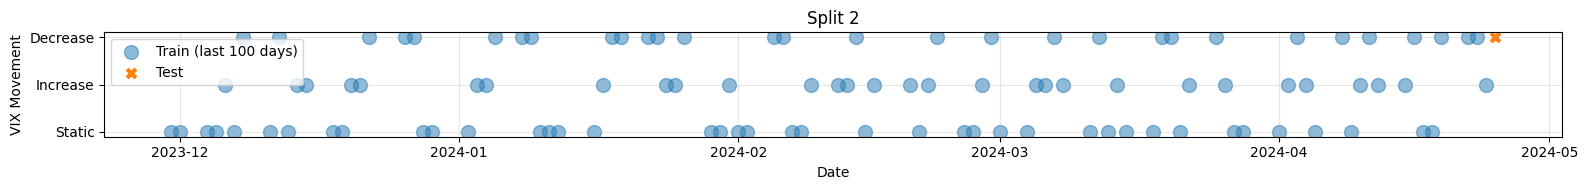

In [ ]:
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.ffill()          # forward fill
    X = X.fillna(0)
    X = X.astype(np.float64)
    return X


def walk_forward_expanding(data, initial_years=15, daily_window=100):

    # Split the features of the model from the target
    X = data.drop(columns=["Intraday_VIX_Move"]).copy()
    y = data["Intraday_VIX_Move"].copy()

    all_splits = []

    initial_window = initial_years * 252  # approx trading days per year

    if initial_window > len(data):
        raise ValueError("The dataset is smaller than the initial years.")

    # INITIAL TRAINING
    X_train_init = X.iloc[:initial_window].copy()
    y_train_init = y.iloc[:initial_window].copy()

    # Clean BEFORE scaling
    X_train_init = clean_features(X_train_init)

    scaler_init = StandardScaler()
    X_train_init_scaled = pd.DataFrame(
        scaler_init.fit_transform(X_train_init),
        index=X_train_init.index,
        columns=X_train_init.columns
    )

    all_splits.append((X_train_init_scaled, None, y_train_init, None))

    # DAILY WALK-FORWARD
    for i in range(initial_window, len(data)):

        X_train = X.iloc[i - daily_window:i].copy()
        y_train = y.iloc[i - daily_window:i].copy()

        X_test = X.iloc[i:i + 1].copy()
        y_test = y.iloc[i:i + 1].copy()

        # 🔹 Clean before scaling
        X_train = clean_features(X_train)

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train),
            index=X_train.index,
            columns=X_train.columns
        )

        # 🔹 Clean test using same logic
        X_test = X_test.replace([np.inf, -np.inf], np.nan)
        X_test = X_test.ffill().fillna(0).astype(np.float64)

        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test),
            index=X_test.index,
            columns=X_test.columns
        )

        all_splits.append((X_train_scaled, X_test_scaled, y_train, y_test))

    return all_splits

splits = walk_forward_expanding(data, initial_years=15, daily_window=100)

for i, (X_train, X_test, y_train, y_test) in enumerate(splits[:5]):
    print(f"Split {i+1}")
    if X_test is None:
        print("Initial training only")
    else:
        print("Train size:", len(X_train), "/ Test size:", len(X_test))
        print("Train From:", X_train.index[0].date(), "to", X_train.index[-1].date())
        print("Test Date:", X_test.index[0].date())
    print("-" * 50)

last_n_days = 100

for i, (X_train, X_test, Y_train, Y_test) in enumerate(splits[1:3]):

    if X_test is None or Y_test is None:
        continue  # skip initial split

    Y_train_last = Y_train.iloc[-last_n_days:]
    Y_test_day = Y_test

    plt.figure(figsize=(16, 2))
    plt.scatter(Y_train_last.index, Y_train_last,
                label='Train (last 100 days)', s=100, alpha=0.5)
    plt.scatter(Y_test_day.index, Y_test_day,
                label='Test', s=40, marker='x', linewidths=3)

    plt.xlabel("Date")
    plt.ylabel("VIX Movement")
    plt.yticks([0, 1, 2], ['Static', 'Increase', 'Decrease'])
    plt.title(f"Split {i+1}")
    plt.legend(loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()